<a href="https://colab.research.google.com/github/isageorgete/Prova19-icoma/blob/main/prova_19_isadora_georgete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prova 19: ANS | Reclamações de Planos de Saúde:
Alvo ($Y$): Reincidente (1) se a operadora de saúde teve mais de 50 reclamações no mesmo
mês.
Desafio: Agrupar dados por CNPJ (usando .groupby()) antes de laborizar a feature.

## Aluna: Isadora Georgete



# Pipeline |  Carregamento e Extração de Dados [Fase 1 - base_igr]

## Importar Dados do Drive

In [123]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Biblioteca de Python

In [124]:
import pandas as pd

## Importar DataFrame [base_igr] - Descrição da base

In [125]:
base_igr= pd.read_csv('/content/drive/MyDrive/prova19-ANS/IGR.csv', sep = ';', low_memory =False)

In [126]:
base_igr

,REGISTRO_ANS,RAZAO_SOCIAL,COBERTURA,IGR,QTD_RECLAMACOES,QTD_BENEFICIARIOS,PORTE_OPERADORA,COMPETENCIA,COMPETENCIA_BENEFICIARIO,DT_ATUALIZACAO
0,515,ALLIANZ SAÚDE S/A,Assistência médica,"0,00",0,211,Pequeno,202603,202602,2026-04-07
1,582,PORTO SEGURO - SEGURO SAÚDE S/A,Assistência médica,"71,45",580,811747,Grande,202603,202602,2026-04-07
2,582,PORTO SEGURO - SEGURO SAÚDE S/A,Exclusivamente odontológica,"0,85",10,1177353,Grande,202603,202602,2026-04-07
3,701,UNIMED SEGUROS SAÚDE S/A,Assistência médica,"58,22",563,966984,Grande,202603,202602,2026-04-07
4,884,ITAUSEG SAÚDE S.A.,Assistência médica,"43,17",3,6949,Pequeno,202603,202602,2026-04-07
...,...,...,...,...,...,...,...,...,...,...
149514,420905,ESTALEIRO ATLÂNTICO SUL S/A,Assistência médica,"0,00",0,5,Pequeno,201501,201501,NaN
149515,420972,ORALPLAN PLANOS DE SAUDE ODONTOLÓGICOS - EIRELI,Exclusivamente odontológica,"0,00",0,1,Pequeno,201501,201501,NaN
149516,421006,ASSOCIAÇÃO SÃO LUIZ SAÚDE,Assistência médica,"0,00",0,625,Pequeno,201501,201501,NaN
149517,421197,SANTA CASA DE MAUÁ SAÚDE,Assistência médica,"0,00",0,80,Pequeno,201501,201501,NaN


# Pipeline | Tratamento e Normalização [Fase 2 - base_igr]

In [127]:
base_igr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149519 entries, 0 to 149518
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   REGISTRO_ANS              149519 non-null  int64 
 1   RAZAO_SOCIAL              149519 non-null  object
 2   COBERTURA                 149519 non-null  object
 3   IGR                       149519 non-null  object
 4   QTD_RECLAMACOES           149519 non-null  int64 
 5   QTD_BENEFICIARIOS         149519 non-null  int64 
 6   PORTE_OPERADORA           149519 non-null  object
 7   COMPETENCIA               149519 non-null  int64 
 8   COMPETENCIA_BENEFICIARIO  149519 non-null  int64 
 9   DT_ATUALIZACAO            87400 non-null   object
dtypes: int64(5), object(5)
memory usage: 11.4+ MB


In [154]:
base_igr.isnull().sum()

,0
REGISTRO_ANS,0
RAZAO_SOCIAL,0
COBERTURA,0
IGR,0
QTD_RECLAMACOES,0
QTD_BENEFICIARIOS,0
PORTE_OPERADORA,0
COMPETENCIA,0
COMPETENCIA_BENEFICIARIO,0


In [ ]:
#Remover coluna irrelevante
base_igr = base_igr.drop(columns=['DT_ATUALIZACAO'])

In [130]:
base_igr['QTD_RECLAMACOES'] = pd.to_numeric(base_igr['QTD_RECLAMACOES'], errors='coerce')

In [131]:
base_igr = base_igr.dropna(subset=['REGISTRO_ANS', 'QTD_RECLAMACOES'])

In [132]:
base_igr['COMPETENCIA'] = base_igr['COMPETENCIA'].astype(str)

# Pipeline | Visualização [Fase 3 - base_igr]

In [133]:
import matplotlib.pyplot as plt

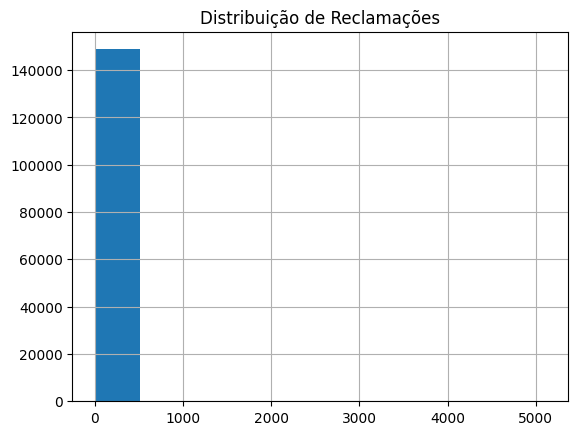

In [134]:
base_igr['QTD_RECLAMACOES'].hist()
plt.title('Distribuição de Reclamações')
plt.show()

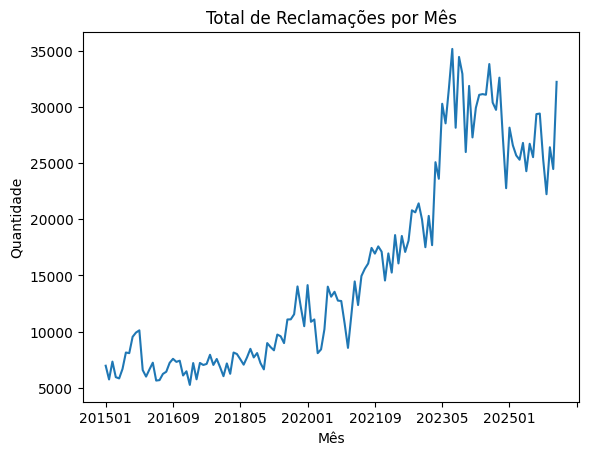

In [135]:
base_igr.groupby('COMPETENCIA')['QTD_RECLAMACOES'].sum().sort_index().plot()
plt.title('Total de Reclamações por Mês')
plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.show()

# Pipeline | Laborização (Feature) [Fase 4 - base_igr]

In [136]:
# REGISTRO_ANS será usado como identificador da operadora (equivalente ao CNPJ)

df_grouped = base_igr.groupby(['REGISTRO_ANS', 'COMPETENCIA']) ['QTD_RECLAMACOES'].sum().reset_index()

In [137]:
df_grouped['Reincidente'] = (df_grouped['QTD_RECLAMACOES'] > 50).astype(int)

In [138]:
import numpy as np

df_grouped['LOG_RECLAMACOES'] = np.log1p(df_grouped['QTD_RECLAMACOES'])

In [139]:
df_grouped['COMPETENCIA_NUM'] = df_grouped['COMPETENCIA'].astype(int)

# Pipeline | Preparação dos Dados [Fase 5 - base_igr]

In [140]:
X = df_grouped[['QTD_RECLAMACOES', 'LOG_RECLAMACOES' ,'COMPETENCIA_NUM']]
# X = df_grouped[['QTD_RECLAMACOES', 'LOG_RECLAMACOES' ]]
y = df_grouped['Reincidente']

# Pipeline | Normalização [Fase 6 - base_igr]

In [141]:
from sklearn.preprocessing import StandardScaler

In [142]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Pipeline | Ingestão Bayesiana [Fase 7 - base_igr]

In [143]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [145]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [146]:
y_pred = model.predict(X_test)
print("Acurácia:", accuracy_score(y_test, y_pred))

Acurácia: 0.9754429821336666


# Pipeline | Avaliação [Fase 8  - base_igr]

In [147]:
from sklearn.metrics import classification_report

In [148]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     26026
           1       0.64      1.00      0.78      1176

    accuracy                           0.98     27202
   macro avg       0.82      0.99      0.88     27202
weighted avg       0.98      0.98      0.98     27202

